In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (77338, 31)


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77338 entries, 0 to 77337
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    77338 non-null  int64  
 1   V1      77338 non-null  float64
 2   V2      77338 non-null  float64
 3   V3      77338 non-null  float64
 4   V4      77338 non-null  float64
 5   V5      77338 non-null  float64
 6   V6      77338 non-null  float64
 7   V7      77338 non-null  float64
 8   V8      77338 non-null  float64
 9   V9      77338 non-null  float64
 10  V10     77338 non-null  float64
 11  V11     77338 non-null  float64
 12  V12     77338 non-null  float64
 13  V13     77338 non-null  float64
 14  V14     77337 non-null  float64
 15  V15     77337 non-null  float64
 16  V16     77337 non-null  float64
 17  V17     77337 non-null  float64
 18  V18     77337 non-null  float64
 19  V19     77337 non-null  float64
 20  V20     77337 non-null  float64
 21  V21     77337 non-null  float64
 22

In [ ]:
df["Class"].value_counts()

,count
Class,
0.0,77149
1.0,188


In [ ]:
print("Class distribution:")
print(df["Class"].value_counts())

print("\nPercentage distribution:")
print(df["Class"].value_counts(normalize=True) * 100)

Class distribution:
Class
0.0    77149
1.0      188
Name: count, dtype: int64

Percentage distribution:
Class
0.0    99.756908
1.0     0.243092
Name: proportion, dtype: float64


In [ ]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
17

Duplicate rows:
303

Data types:
Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object


In [ ]:
missing = df.isnull().sum()

print(missing[missing > 0])

V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
print(df[df.isnull().any(axis=1)])

        Time        V1        V2        V3        V4        V5       V6  \
77337  57006  1.380239 -1.328341  1.488601 -1.259442 -2.253642 -0.19398   

             V7        V8        V9  ...  V21  V22  V23  V24  V25  V26  V27  \
77337 -1.799733  0.139147 -1.245753  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

       V28  Amount  Class  
77337  NaN     NaN    NaN  

[1 rows x 31 columns]


In [ ]:
# Remove rows where the target label is missing
df = df.dropna(subset=["Class"]).copy()

print("Shape after removing missing target:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

Shape after removing missing target: (77337, 31)
Missing values remaining: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 303


In [ ]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

print("Total duplicate rows:", len(duplicates))
print("\nClass distribution among duplicate rows:")
print(duplicates["Class"].value_counts())

duplicates.head(10)

Total duplicate rows: 532

Class distribution among duplicate rows:
Class
0.0    532
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
35,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
32,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
33,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
112,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
113,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
114,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
115,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
220,145,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0
221,145,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0


In [ ]:
# Remove duplicate transactions
before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)
print("Final dataset shape:", df.shape)

Rows before removing duplicates: 77337
Rows after removing duplicates: 77034
Duplicates removed: 303
Final dataset shape: (77034, 31)


In [ ]:
print(df["Class"].value_counts())
print("\nFraud percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.0    76846
1.0      188
Name: count, dtype: int64

Fraud percentage:
Class
0.0    99.755952
1.0     0.244048
Name: proportion, dtype: float64


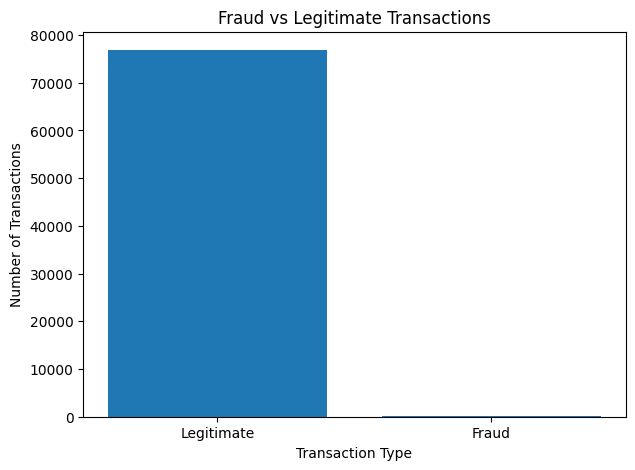

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], class_counts.values)
plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Type")
plt.show()

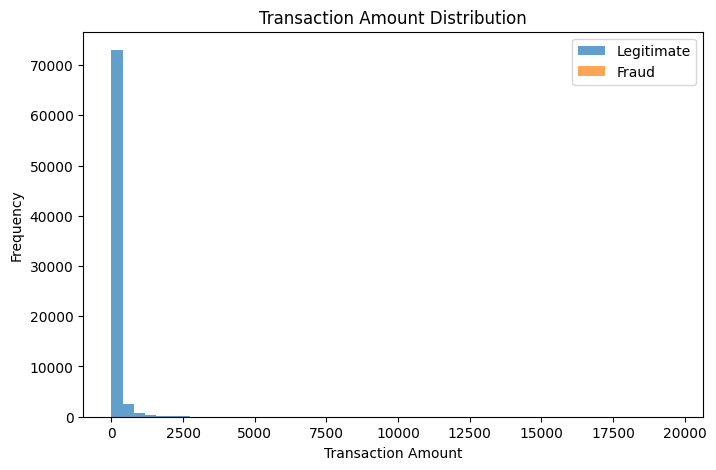

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.7, label="Legitimate")
plt.hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.7, label="Fraud")

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

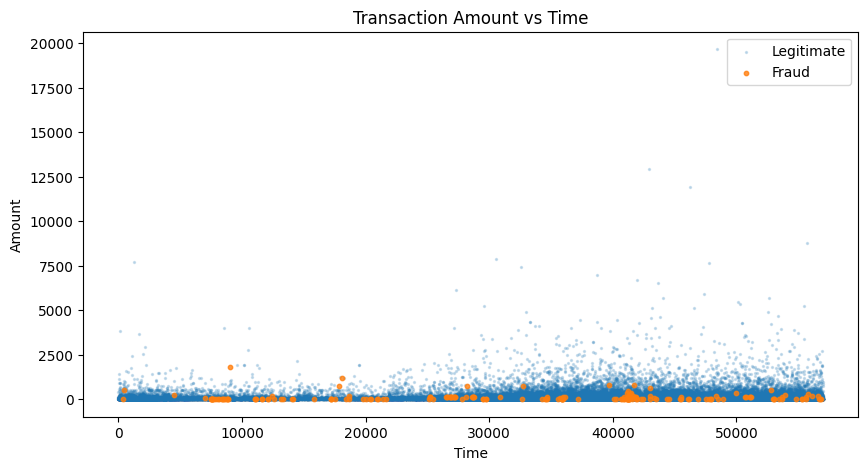

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df[df["Class"] == 0]["Time"],
    df[df["Class"] == 0]["Amount"],
    s=2,
    alpha=0.2,
    label="Legitimate"
)

plt.scatter(
    df[df["Class"] == 1]["Time"],
    df[df["Class"] == 1]["Amount"],
    s=10,
    alpha=0.8,
    label="Fraud"
)

plt.title("Transaction Amount vs Time")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [ ]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"].astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (77034, 30)
Target shape: (77034,)

Target distribution:
Class
0    76846
1      188
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (61627, 30)
Test set: (15407, 30)

Training class distribution:
Class
0    61477
1      150
Name: count, dtype: int64

Test class distribution:
Class
0    15369
1       38
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Average Precision (PR-AUC):", round(
    average_precision_score(y_test, y_prob), 4
))

Confusion Matrix:
[[15051   318]
 [    2    36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9793    0.9895     15369
           1     0.1017    0.9474    0.1837        38

    accuracy                         0.9792     15407
   macro avg     0.5508    0.9633    0.5866     15407
weighted avg     0.9977    0.9792    0.9875     15407

ROC-AUC: 0.9939
Average Precision (PR-AUC): 0.6079


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("Average Precision (PR-AUC):", round(
    average_precision_score(y_test, rf_prob), 4
))

Confusion Matrix:
[[15367     2]
 [    8    30]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     15369
           1     0.9375    0.7895    0.8571        38

    accuracy                         0.9994     15407
   macro avg     0.9685    0.8947    0.9284     15407
weighted avg     0.9993    0.9994    0.9993     15407

ROC-AUC: 0.9717
Average Precision (PR-AUC): 0.8954


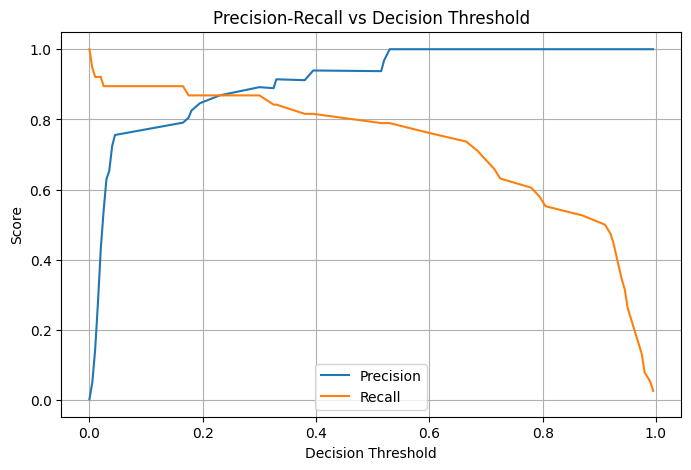

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Decision Threshold")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", round(best_threshold, 4))
print("Best F1 score:", round(best_f1, 4))

Best threshold: 0.53
Best F1 score: 0.8824


In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("\nTraining classes:")
print(y_train_final.value_counts())

print("\nValidation classes:")
print(y_val.value_counts())

Training: (49301, 30)
Validation: (12326, 30)

Training classes:
Class
0    49181
1      120
Name: count, dtype: int64

Validation classes:
Class
0    12296
1       30
Name: count, dtype: int64


In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

print("Final training completed!")

Final training completed!


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get fraud probabilities on validation data
val_prob = rf_final.predict_proba(X_val)[:, 1]

# Calculate precision, recall for different thresholds
val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    val_prob
)

# Calculate F1 for every threshold
val_f1_scores = (
    2 * val_precision[:-1] * val_recall[:-1]
    / (val_precision[:-1] + val_recall[:-1] + 1e-10)
)

# Find threshold with highest F1
best_val_index = np.argmax(val_f1_scores)

best_val_threshold = val_thresholds[best_val_index]
best_val_f1 = val_f1_scores[best_val_index]

print("Best validation threshold:", round(best_val_threshold, 4))
print("Best validation F1:", round(best_val_f1, 4))

Best validation threshold: 0.395
Best validation F1: 0.8929


In [ ]:
# Evaluate on the untouched final test set
test_prob = rf_final.predict_proba(X_test)[:, 1]

# Apply the threshold selected using validation data
test_pred = (test_prob >= best_val_threshold).astype(int)

print("Final Test Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, test_pred, digits=4))

print("Final Test ROC-AUC:",
      round(roc_auc_score(y_test, test_prob), 4))

print("Final Test PR-AUC:",
      round(average_precision_score(y_test, test_prob), 4))

Final Test Confusion Matrix:
[[15365     4]
 [    7    31]]

Final Test Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9997    0.9996     15369
           1     0.8857    0.8158    0.8493        38

    accuracy                         0.9993     15407
   macro avg     0.9426    0.9078    0.9245     15407
weighted avg     0.9993    0.9993    0.9993     15407

Final Test ROC-AUC: 0.9848
Final Test PR-AUC: 0.903


In [ ]:
print("Selected validation threshold:", best_val_threshold)
print("Validation F1:", best_val_f1)

Selected validation threshold: 0.395
Validation F1: 0.8928571428073979


In [ ]:
import joblib

joblib.dump(rf_final, "fraud_risk_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print("Model exists:", os.path.exists("fraud_risk_model.joblib"))
print("Model size:", os.path.getsize("fraud_risk_model.joblib") / (1024 * 1024), "MB")

Model exists: True
Model size: 1.8110437393188477 MB


In [ ]:
from google.colab import files

files.download("fraud_risk_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Test the trained model on one real transaction from the test set

sample = X_test.iloc[[0]]

probability = rf_final.predict_proba(sample)[0][1]

risk_score = probability * 100

if risk_score >= 70:
    risk_level = "HIGH"
elif risk_score >= 30:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

is_fraud = probability >= best_val_threshold

print("Fraud Probability:", round(probability, 4))
print("Risk Score:", round(risk_score, 2))
print("Risk Level:", risk_level)
print("Fraud Decision:", is_fraud)

Fraud Probability: 0.0
Risk Score: 0.0
Risk Level: LOW
Fraud Decision: False


In [ ]:
# Find one legitimate and one fraud transaction from the test set

legit_index = y_test[y_test == 0].index[0]
fraud_index = y_test[y_test == 1].index[0]

legit_sample = X_test.loc[[legit_index]]
fraud_sample = X_test.loc[[fraud_index]]

# Predictions
legit_prob = rf_final.predict_proba(legit_sample)[0][1]
fraud_prob = rf_final.predict_proba(fraud_sample)[0][1]

print("LEGITIMATE TRANSACTION")
print("----------------------")
print("Actual Class: 0")
print("Fraud Probability:", round(legit_prob, 4))
print("Risk Score:", round(legit_prob * 100, 2))
print("Prediction:", int(legit_prob >= best_val_threshold))

print("\nFRAUD TRANSACTION")
print("-----------------")
print("Actual Class: 1")
print("Fraud Probability:", round(fraud_prob, 4))
print("Risk Score:", round(fraud_prob * 100, 2))
print("Prediction:", int(fraud_prob >= best_val_threshold))

LEGITIMATE TRANSACTION
----------------------
Actual Class: 0
Fraud Probability: 0.0
Risk Score: 0.0
Prediction: 0

FRAUD TRANSACTION
-----------------
Actual Class: 1
Fraud Probability: 0.165
Risk Score: 16.5
Prediction: 0


In [ ]:
# Find correctly detected fraud and missed fraud

test_results = X_test.copy()

test_results["actual"] = y_test
test_results["probability"] = test_prob
test_results["prediction"] = test_pred

# Correctly detected fraud
caught_fraud = test_results[
    (test_results["actual"] == 1) &
    (test_results["prediction"] == 1)
]

# Missed fraud
missed_fraud = test_results[
    (test_results["actual"] == 1) &
    (test_results["prediction"] == 0)
]

# Correctly detected legitimate
correct_legit = test_results[
    (test_results["actual"] == 0) &
    (test_results["prediction"] == 0)
]

print("Fraud correctly detected:", len(caught_fraud))
print("Fraud missed:", len(missed_fraud))
print("Legitimate correctly detected:", len(correct_legit))

print("\nExample caught fraud probability:")
print(round(caught_fraud["probability"].iloc[0], 4))

print("\nExample missed fraud probability:")
print(round(missed_fraud["probability"].iloc[0], 4))

print("\nExample legitimate probability:")
print(round(correct_legit["probability"].iloc[0], 4))

Fraud correctly detected: 31
Fraud missed: 7
Legitimate correctly detected: 15365

Example caught fraud probability:
0.74

Example missed fraud probability:
0.165

Example legitimate probability:
0.0


In [ ]:
import joblib

model_package = {
    "model": rf_final,
    "threshold": float(best_val_threshold),
    "features": list(X_train.columns),
    "model_name": "Random Forest",
    "metrics": {
        "precision": 0.8857,
        "recall": 0.8158,
        "f1": 0.8493,
        "roc_auc": 0.9848,
        "pr_auc": 0.9030
    }
}

joblib.dump(model_package, "fraud_detection_model_package.joblib")

print("Complete model package saved!")

Complete model package saved!


In [ ]:
package = joblib.load("fraud_detection_model_package.joblib")

print("Model:", package["model_name"])
print("Threshold:", package["threshold"])
print("Number of features:", len(package["features"]))
print("Features:", package["features"])
print("Metrics:", package["metrics"])

Model: Random Forest
Threshold: 0.395
Number of features: 30
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Metrics: {'precision': 0.8857, 'recall': 0.8158, 'f1': 0.8493, 'roc_auc': 0.9848, 'pr_auc': 0.903}


In [ ]:
from google.colab import files

files.download("fraud_detection_model_package.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

# Use the fraud transaction that our model correctly detected
caught_index = caught_fraud.index[0]

transaction = X_test.loc[caught_index].to_dict()

print(json.dumps(transaction, indent=2))

{
  "Time": 28755.0,
  "V1": -30.552380043581,
  "V2": 16.7133892350242,
  "V3": -31.1036848245812,
  "V4": 6.53498386355181,
  "V5": -22.105531524316,
  "V6": -4.97769196369245,
  "V7": -20.371513594495,
  "V8": 20.0072083651213,
  "V9": -3.56573779124378,
  "V10": -7.7310714411342,
  "V11": 3.8294273949908,
  "V12": -5.31433227604015,
  "V13": 1.44693027992913,
  "V14": -4.57926372815218,
  "V15": -0.142299360010106,
  "V16": -4.99784830436345,
  "V17": -10.9614103561188,
  "V18": -4.64148195920404,
  "V19": 0.567056279787444,
  "V20": 1.73364399368955,
  "V21": 1.8165201713562,
  "V22": -2.28868550494101,
  "V23": -1.46054449877578,
  "V24": 0.183179482716819,
  "V25": 2.20820917836653,
  "V26": -0.208823971247713,
  "V27": 1.23263629519904,
  "V28": 0.356660010884047,
  "Amount": 99.99
}
